A shopping mall wants to segment its customers based on their spending patterns. You are given a dataset containing customer details, including Annual Income and Spending Score. Your task is to apply K-Means Clustering to group customers into meaningful segments and analyze the results. Use Mall Customers Dataset from Kaggle.

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
mall_customers = pd.read_csv('datasets/Mall_Customers.csv')

In [4]:
mall_customers

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


Removing CustomerID from the dataset

In [5]:
mall_customers.drop(columns=['CustomerID'], inplace=True)

In [6]:
mall_customers

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


Converting the Genre feature to numerical datatype.

In [7]:
mall_customers["Genre"] = mall_customers["Genre"].apply(lambda x: 1 if x == "Male" else 0)

In [8]:
mall_customers

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [9]:
mall_customers.describe()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,0.440000,38.850000,60.560000,50.200000
std,0.497633,13.969007,26.264721,25.823522
min,0.000000,18.000000,15.000000,1.000000
25%,0.000000,28.750000,41.500000,34.750000
50%,0.000000,36.000000,61.500000,50.000000
75%,1.000000,49.000000,78.000000,73.000000
max,1.000000,70.000000,137.000000,99.000000


Plotting the histograms

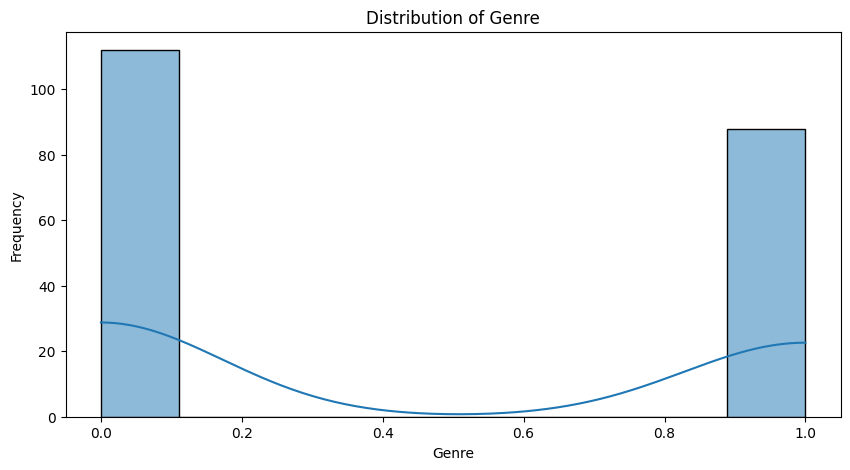

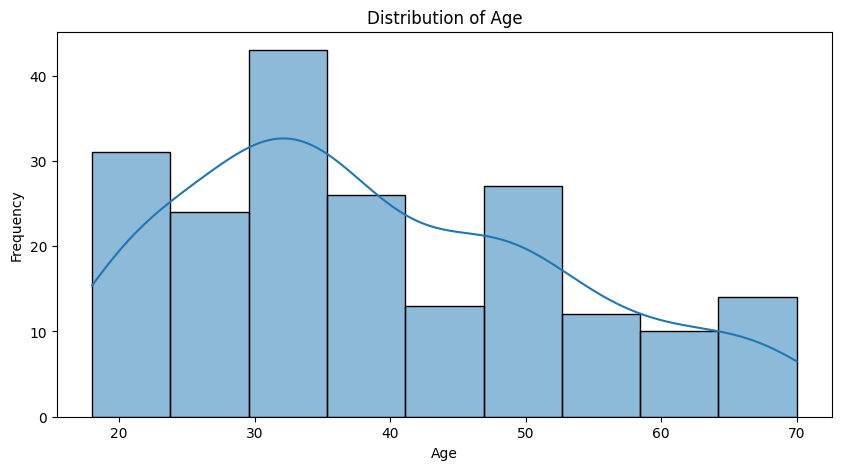

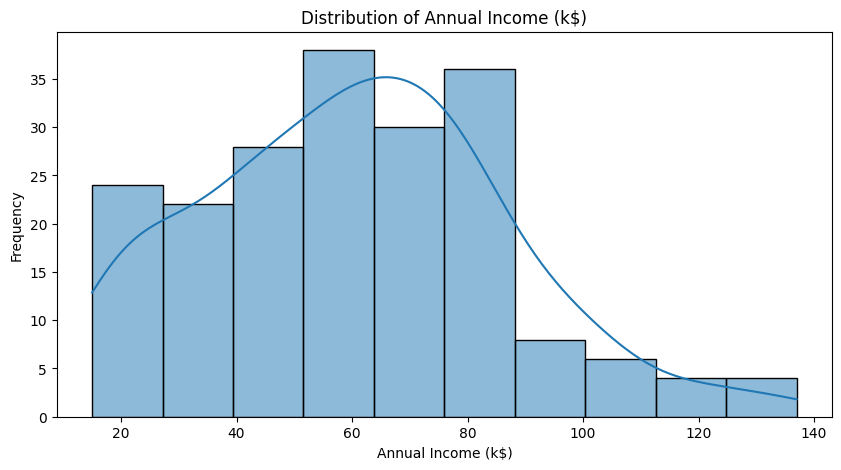

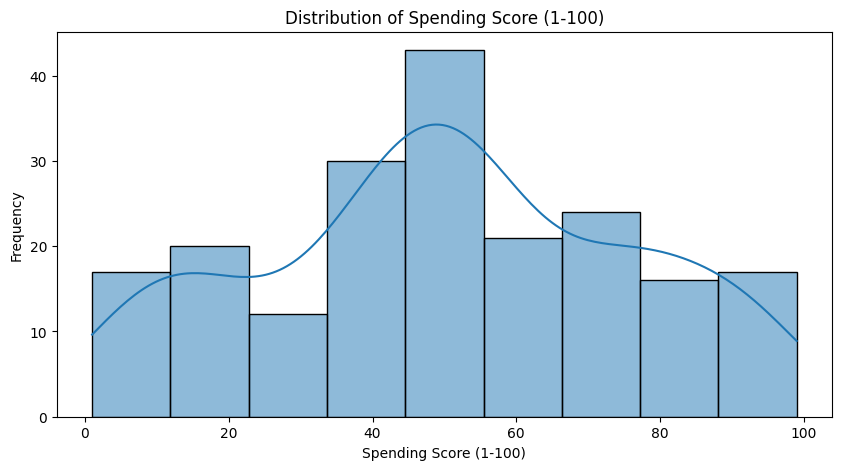

In [10]:
for column in mall_customers.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(mall_customers[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

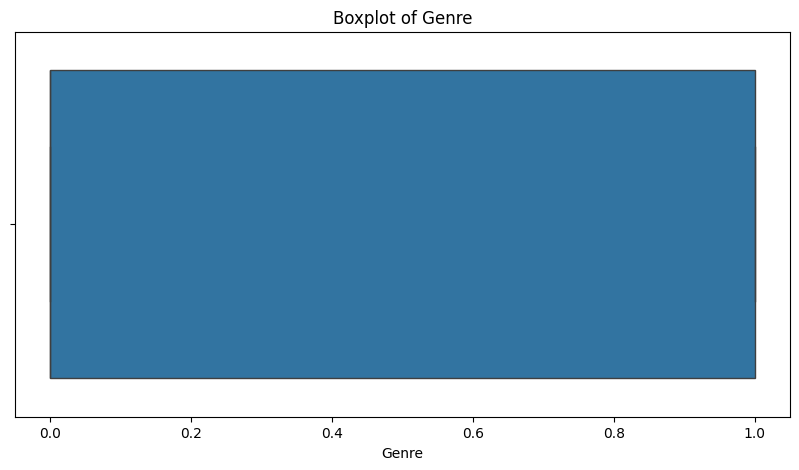

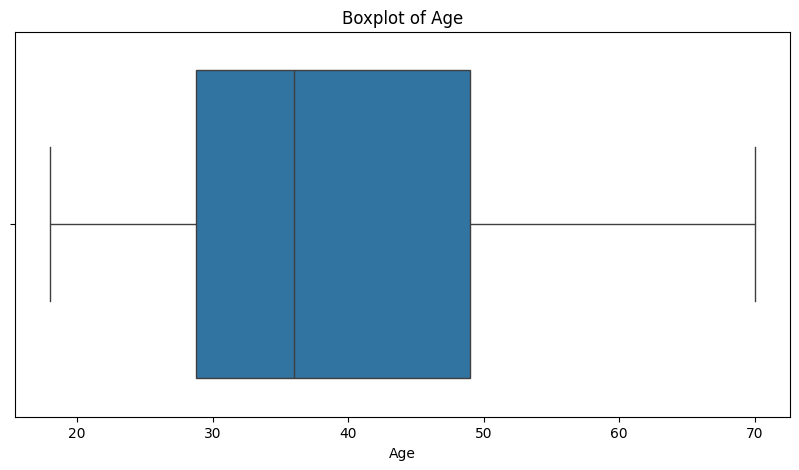

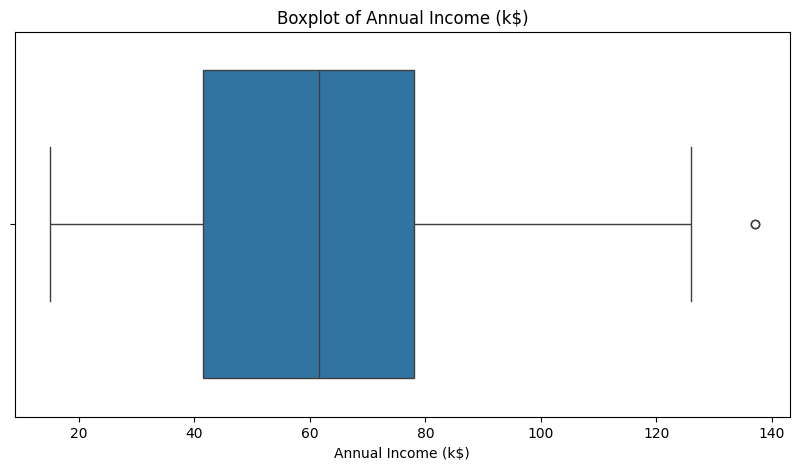

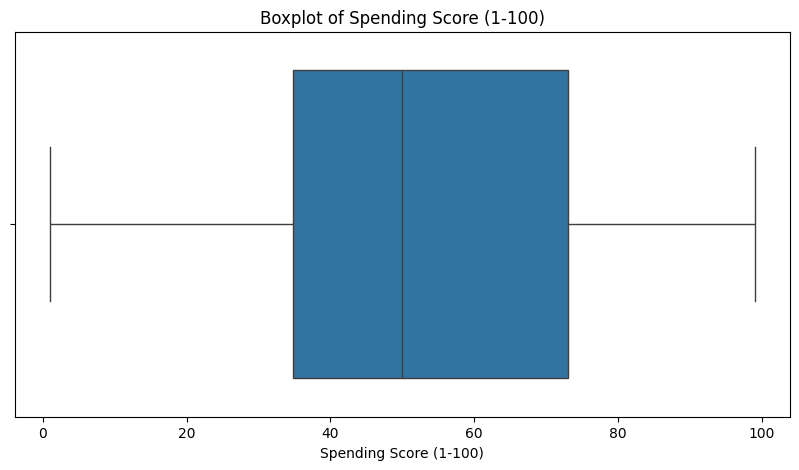

In [11]:
for column in mall_customers.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=mall_customers[column])
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

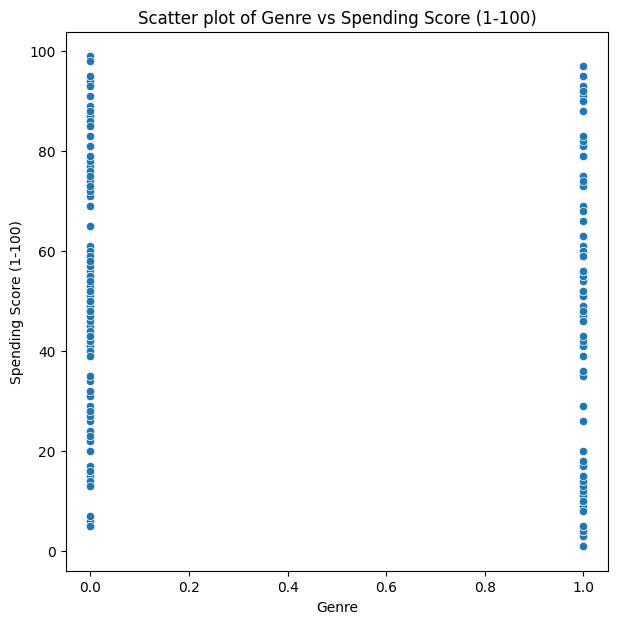

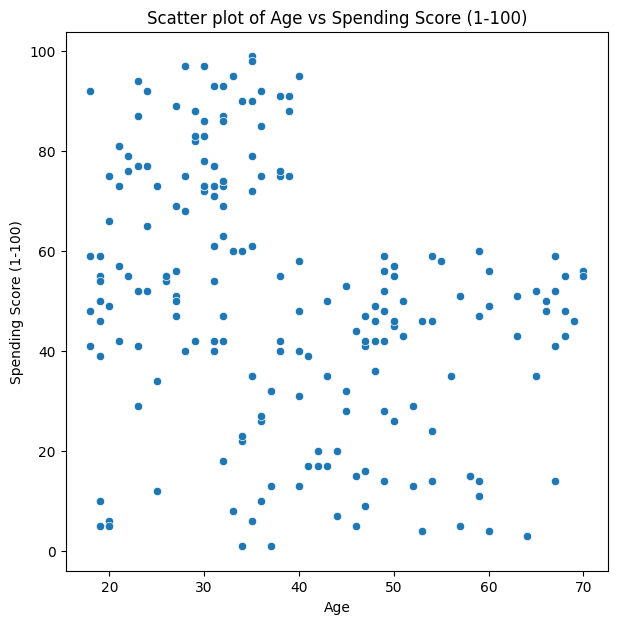

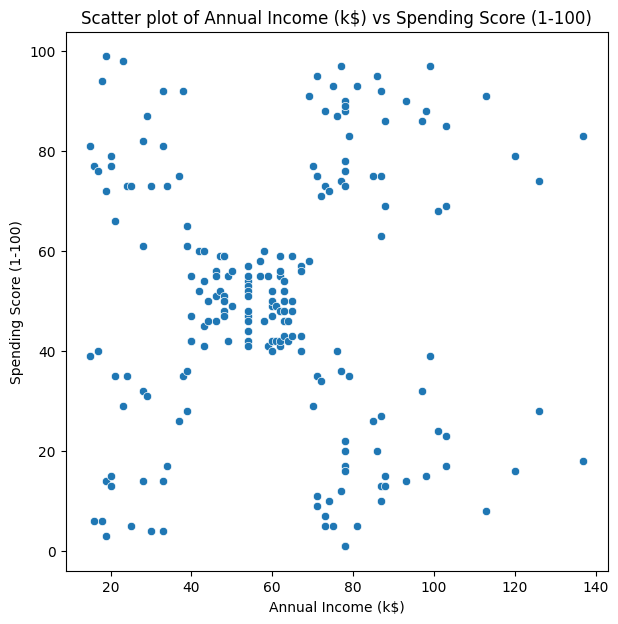

In [12]:
for column in mall_customers.columns[:-1]:
    plt.figure(figsize = (7, 7))
    sns.scatterplot(data=mall_customers, x=column, y="Spending Score (1-100)", edgecolor="w")
    plt.title(f"Scatter plot of {column} vs Spending Score (1-100)")
    plt.xlabel(column)
    plt.ylabel("Spending Score (1-100)")
    plt.show()

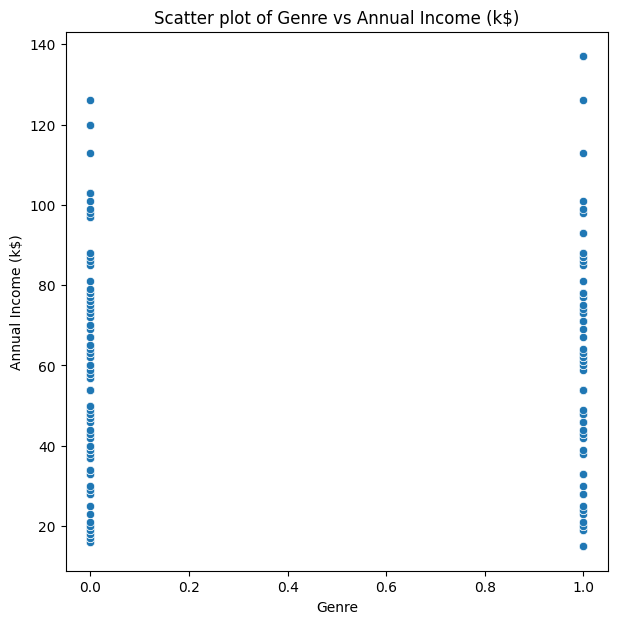

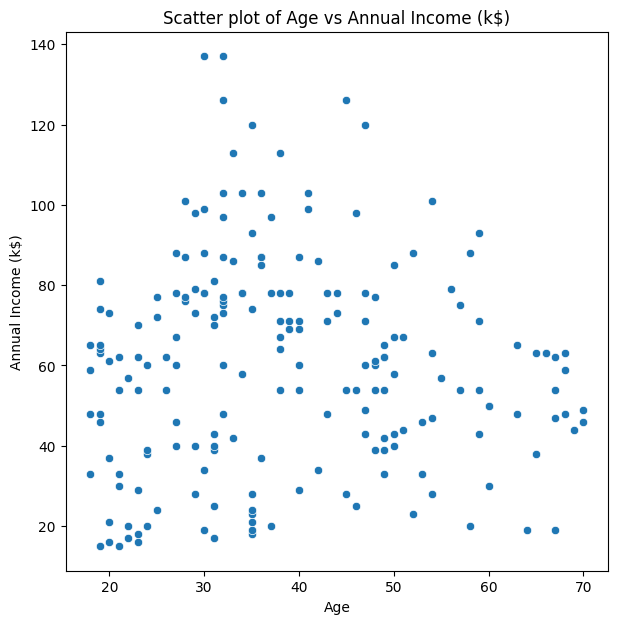

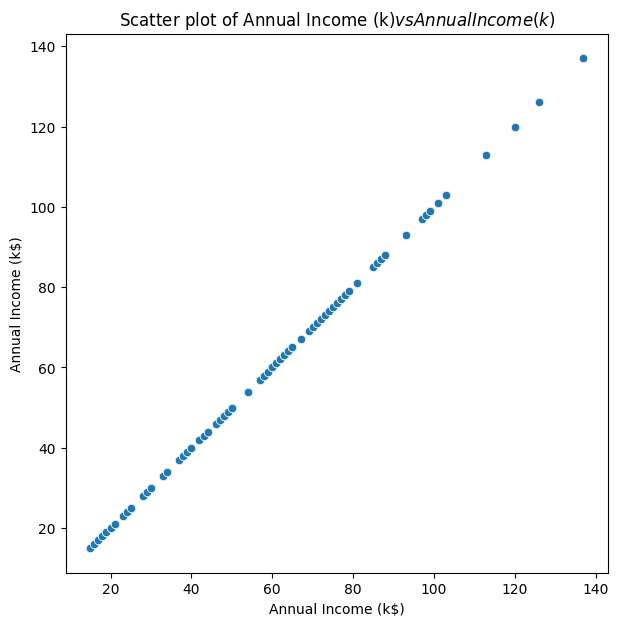

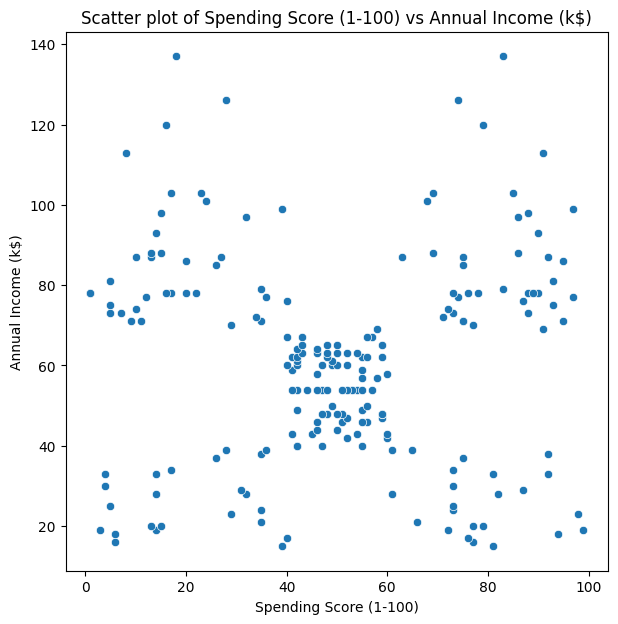

In [17]:
for column in mall_customers.columns:
    plt.figure(figsize=(7, 7))
    sns.scatterplot(data=mall_customers, x=column, y="Annual Income (k$)", edgecolor="w")
    plt.title(f"Scatter plot of {column} vs Annual Income (k$)")
    plt.xlabel(column)
    plt.ylabel("Annual Income (k$)")
    plt.show()

Using KMeans Clustering to create clusters

In [124]:
X = mall_customers.copy()

In [125]:
n_clusters = 5
km_01 = KMeans(n_clusters=n_clusters, random_state=42)

In [126]:
km_01.fit_predict(X[["Annual Income (k$)", "Spending Score (1-100)"]])

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [127]:
X["Cluster"] = km_01.labels_

Calculating the silhouette score for clusters = 5

In [128]:
sc = silhouette_score(X[["Annual Income (k$)", "Spending Score (1-100)"]], X["Cluster"])
print(f"Silhouette Score: {sc:.2f}")

Silhouette Score: 0.55


<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

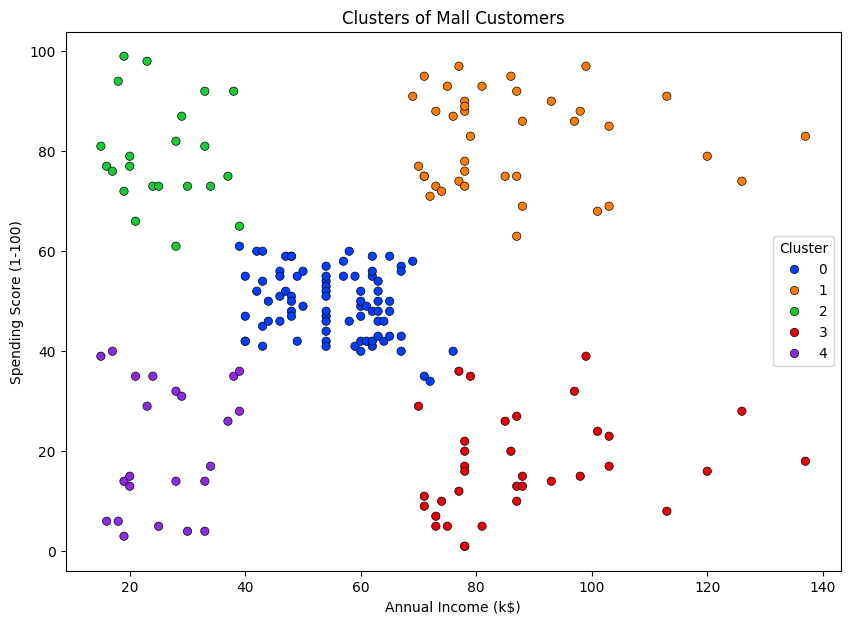

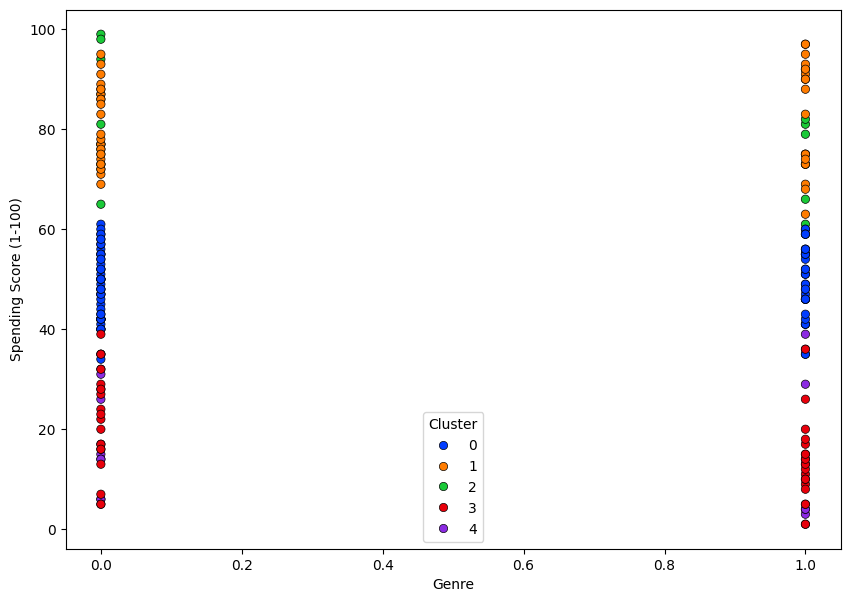

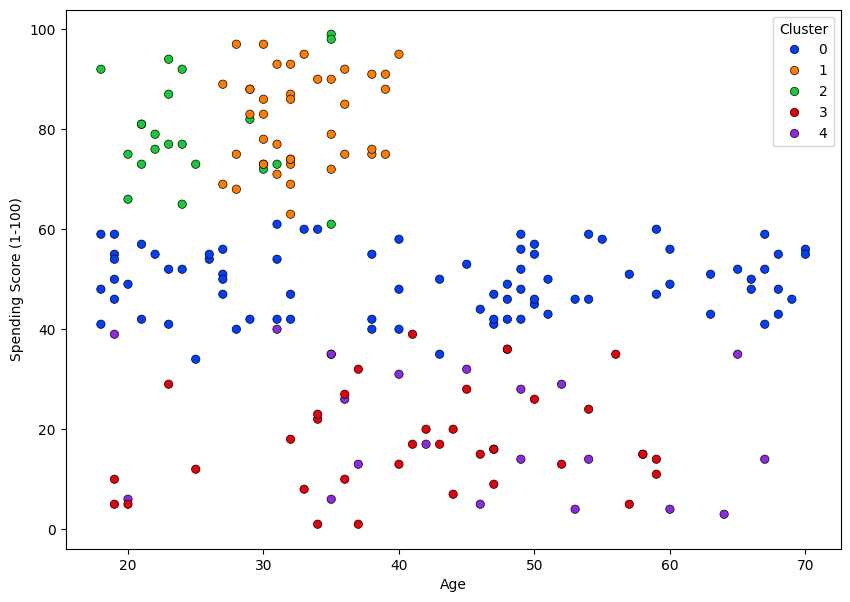

In [129]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=X, x="Annual Income (k$)", y="Spending Score (1-100)", hue="Cluster", palette="bright", edgecolor="k")
plt.title("Clusters of Mall Customers")
plt.figure(figsize=(10, 7))
sns.scatterplot(data=X, x="Genre", y="Spending Score (1-100)", hue="Cluster", palette="bright", edgecolor="k")
plt.figure(figsize=(10, 7))
sns.scatterplot(data=X, x="Age", y="Spending Score (1-100)", hue="Cluster", palette="bright", edgecolor="k")

Here we have selected the two features **Annual Income** and **Spending Score** for kmeans clustering as their scatter plot showed some grouping. We are able to form 5 clusters.
From the first graph:
* we are able to find that cluster-0(cluster in the center) contains people who have an annual income ranging between 40k$ to 75k$ have a moderate spending habit.
* Cluster-1 and Cluster-2 show higher spending score eventhough they have a lower annual income(10k$ to 40k$)
* Cluster-3 and CLuster-4 shows a group of people that have lower spending score(2 - 40), as they have a lower annual income(10k$ to 40k$) compared to others
